In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

words = open("../names.txt", "r").read().splitlines()

In [2]:
# 1. create table to map from char to index
chars = sorted(list(set("".join(words))))
stoi = {char: i+1 for i, char in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vacab_size = len(itos)
print(f"vocabulary size: {vacab_size} sample size {len(words)}")

vocabulary size: 27 sample size 32033


In [9]:
# 2. build data set with specific context window
def build_dataset(words, block_size=3):
    X = []
    Y = []
    for word in words: 
        context = [0] * block_size
        for ch in word + '.':
            index = stoi[ch]
            X.append(context)
            Y.append(index)
            context = context[1:] + [index]
    return torch.tensor(X), torch.tensor(Y)

# Set up training/val/test data sets
# 80% training, 10% eval, 10% test
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
block_size = 3
g = torch.Generator().manual_seed(42)

Xtr, Ytr = build_dataset(words[: n1], block_size)
Xdev, Ydev = build_dataset(words[n1: n2], block_size)
Xtest, Ytest = build_dataset(words[n2:], block_size)

print(f"Xtr shape {Xtr.shape} Ytr shape {Ytr.shape}")

Xtr shape torch.Size([182778, 3]) Ytr shape torch.Size([182778])


In [24]:
from typing import Any

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        # Xvaier initialize weights
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in ** 0.5)
        # Initialize bias as zeroes if bias is true
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [66]:
from typing import Any

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #running mean and var
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x: torch.Tensor):
        #compute batch norm in training mode
        if self.training:
            mean = x.mean(dim=0, keepdim=True)
            var = x.var(dim=0, keepdim=True, unbiased=False)
        else:
            mean = self.running_mean
            var = self.running_var
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        self.out = self.gamma * x_norm + self.beta
        # Update running mean and bar
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [26]:
from typing import Any
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [72]:
# embeddings: 27 x 10
emb_size = 10
C = torch.randn((vacab_size, emb_size), generator=g)
in_dim = emb_size * block_size
hidden_dim = 100
out_dim = vacab_size

# 6 layers MLP
layers = [
    # input layer
    Linear(in_dim, hidden_dim, bias=False), 
    BatchNorm1d(hidden_dim),
    Tanh(),
    # hidden layer 1
    Linear(hidden_dim, hidden_dim, bias=False),
    BatchNorm1d(hidden_dim),
    Tanh(),
    # hidden layer 2
    Linear(hidden_dim, hidden_dim, bias=False),
    BatchNorm1d(hidden_dim),
    Tanh(),
    # hidden layer 3
    Linear(hidden_dim, hidden_dim, bias=False),
    BatchNorm1d(hidden_dim),
    Tanh(),
    # hidden layer 4
    Linear(hidden_dim, hidden_dim, bias=False),
    BatchNorm1d(hidden_dim),
    Tanh(),
    # output layer, no tanh
    # in production no batch norm as well, just Linear(hidden_dim, out_dim)
    Linear(hidden_dim, out_dim, bias=False),
    BatchNorm1d(out_dim),
]

# Adjust initialized parameters
with torch.no_grad():
    # output layer: make less confident to avoid initial loss too large
    layers[-1].gamma *= 0.1
    # apply tanh gain to weights of all other layers
    for layer in layers[: -1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True
print(f"Total params: {sum(p.nelement() for p in parameters)}") # number of parameters in total

Total params: 47024


In [73]:
batch_size = 64
max_steps = 200000

ud = [] # update to date ratio change history
lossi = [] #log loss change history

for step in range(max_steps):
    # 1. select a random mini-batch from training data set
    batch_idxes = torch.randint(0, Xtr.shape[0], (batch_size,))

    # 2. prepare training data with embeddings
    # x: (batch_size, block_size, emb_size) -> (batch_size, block_size * emb_size) 
    # y: (batch_size,)
    x = C[Xtr[batch_idxes]].view(-1, in_dim)
    y = Ytr[batch_idxes]

    # 3. forward pass
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)

    # 4. backward pass
    for layer in layers:
        layer.out.retain_grad() #Retain grad for non-leaf node, debug only
    for p in parameters:
        p.grad = None
    loss.backward()

    # 5. optimize with learning rate decay
    lr = 0.1 if step < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    # track stats
    if step % 10000 == 0: # print every once in a while
        print(f'{step:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append( [((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if step >= 1000:
        break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2955


layer 2 (      Tanh): mean -0.00, std 0.64, saturated: 2.98%
layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 3.05%
layer 8 (      Tanh): mean +0.00, std 0.65, saturated: 2.94%
layer 11 (      Tanh): mean -0.00, std 0.65, saturated: 2.52%
layer 14 (      Tanh): mean +0.01, std 0.65, saturated: 2.50%


Text(0.5, 1.0, 'activation distribution')

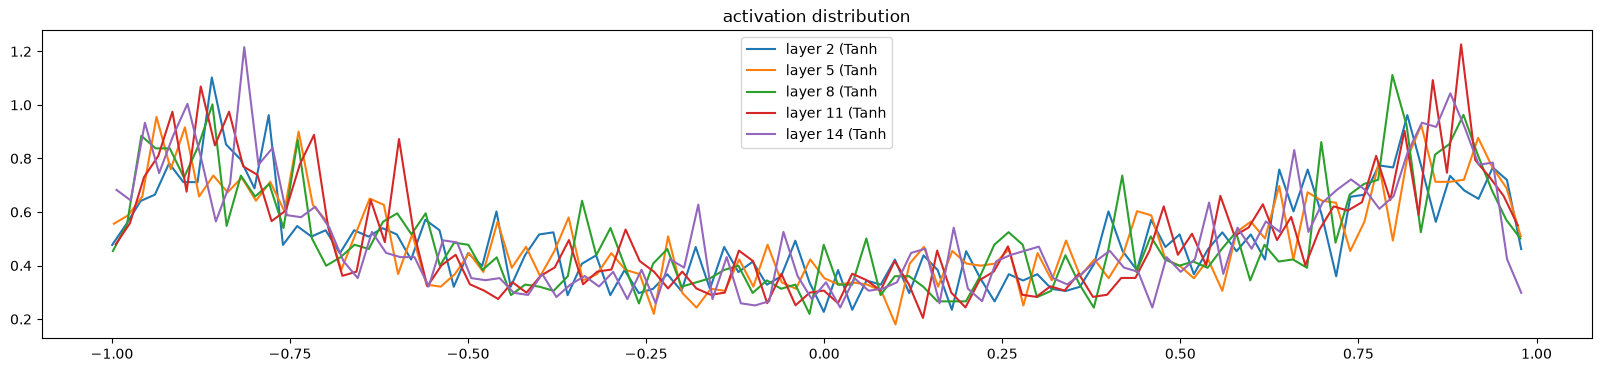

In [74]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 1.882041e-03
layer 5 (      Tanh): mean -0.000000, std 1.639925e-03
layer 8 (      Tanh): mean -0.000000, std 1.545320e-03
layer 11 (      Tanh): mean -0.000000, std 1.493677e-03
layer 14 (      Tanh): mean -0.000000, std 1.469148e-03


Text(0.5, 1.0, 'gradient distribution')

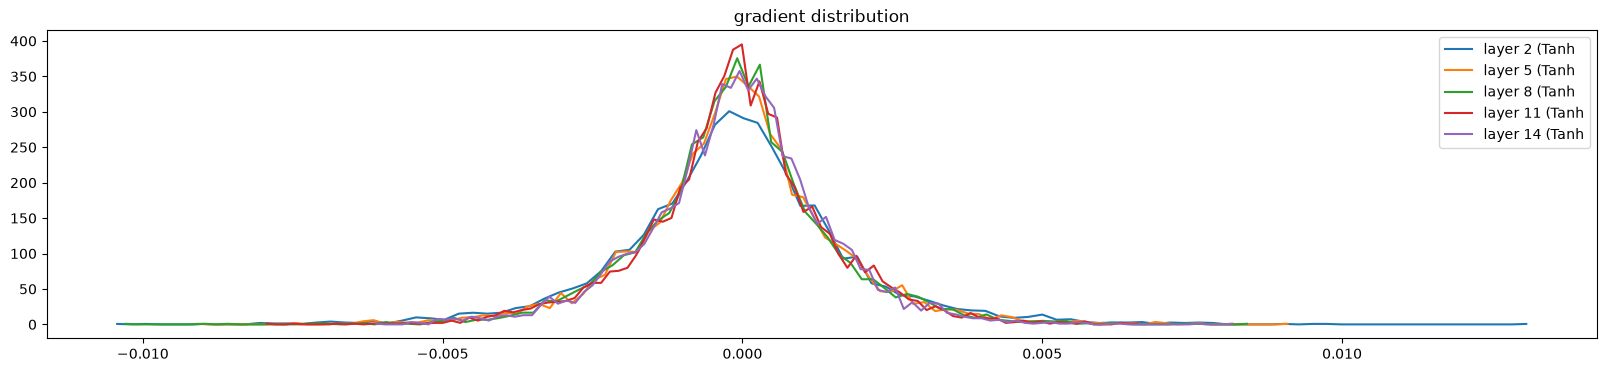

In [76]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 6.542820e-03 | grad:data ratio 6.654473e-03
weight  (30, 100) | mean +0.000111 | std 6.768862e-03 | grad:data ratio 2.208960e-02
weight (100, 100) | mean +0.000032 | std 5.364158e-03 | grad:data ratio 3.193669e-02
weight (100, 100) | mean +0.000005 | std 5.011351e-03 | grad:data ratio 3.017171e-02
weight (100, 100) | mean +0.000025 | std 4.506203e-03 | grad:data ratio 2.691785e-02
weight (100, 100) | mean -0.000021 | std 4.311584e-03 | grad:data ratio 2.573521e-02
weight  (100, 27) | mean -0.000042 | std 8.276532e-03 | grad:data ratio 4.944605e-02


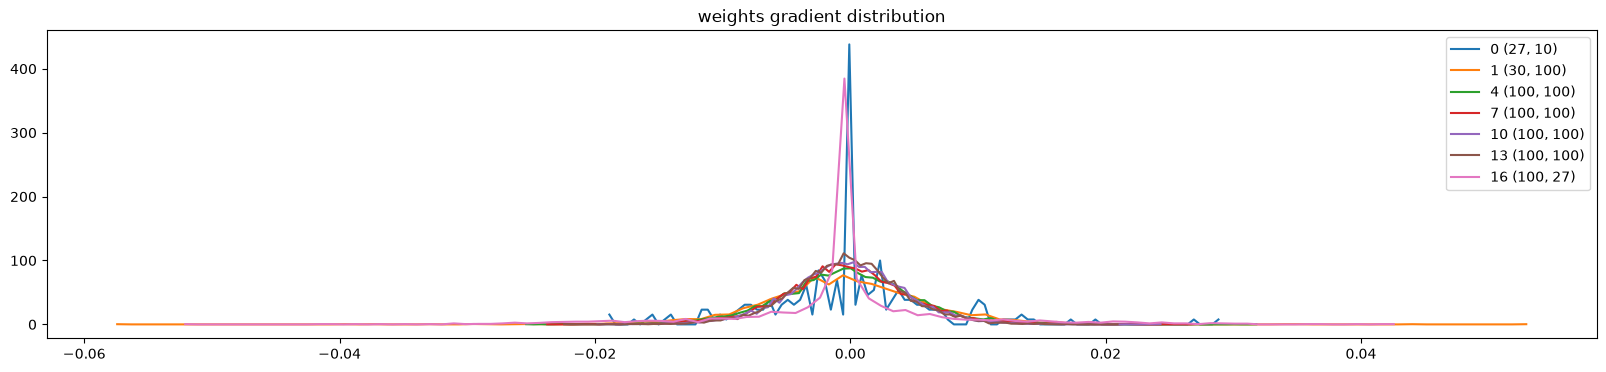

In [78]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

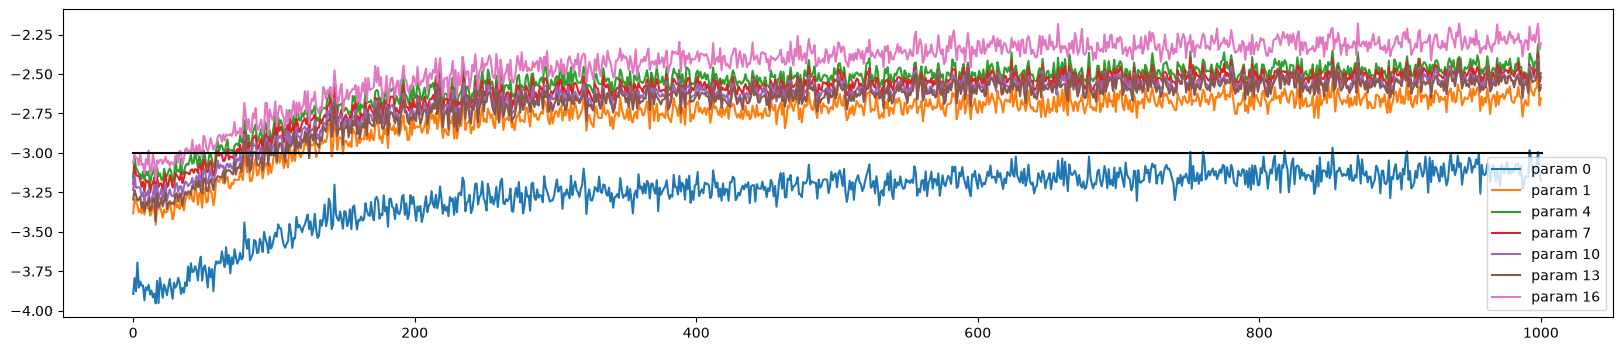

In [79]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);